# AI Risk Manager
## Cost-Sensitive Transaction Fraud Risk Engine

### Track
Razorpay AI Buildathon - Track 02: AI Risk Manager

### Objective

Build a defense-only fraud risk detection system that identifies
potentially fraudulent transactions and helps merchants make
risk-aware decisions.

The system will eventually produce three possible decisions:

- APPROVE
- REVIEW
- BLOCK

The model will be evaluated using precision and recall on a held-out
test set. Because false positives can create legitimate-customer
friction while false negatives can cause financial loss, the final
system will also evaluate false-positive and false-negative costs.

### Important Dataset Disclaimer

This project uses a publicly available credit-card fraud benchmark
dataset for model development and evaluation.

The dataset is not Razorpay's proprietary data and does not represent
Razorpay's internal transaction patterns or Indian payment behavior.

## 1. Problem Definition

### Business Problem

Merchants need to identify potentially fraudulent transactions while
avoiding unnecessary rejection of legitimate customers.

A fraud detection system therefore has two competing objectives:

1. Detect as much fraud as possible.
2. Avoid incorrectly flagging legitimate transactions.

The cost of these two types of errors is different.

### False Positive

A legitimate transaction is incorrectly identified as fraud.

Potential impact:

- legitimate customer friction
- unnecessary transaction rejection
- loss of customer trust

### False Negative

A fraudulent transaction is incorrectly identified as legitimate.

Potential impact:

- financial loss
- fraud-related operational cost
- merchant risk

The final AI Risk Manager will therefore not optimize only for
accuracy. It will evaluate precision, recall, PR-AUC and the
business cost associated with different decision thresholds.

## 2. Dataset Overview

The dataset contains transaction-level numerical features and a binary
target variable.

### Target Variable

`Class`

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

### Features

- `Time` = elapsed time in seconds from the first transaction
- `V1` to `V28` = anonymized PCA-transformed transaction features
- `Amount` = transaction amount

The original meanings of `V1` to `V28` are not available in the
public dataset, so they will be treated as anonymized numerical
features without assigning unsupported business meanings.

## 3. Import Libraries

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## 4. Load Dataset

In [48]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


## 5. Basic Dataset Inspection

We first inspect the number of observations, features and column
names before performing detailed analysis.

In [49]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 284807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## 6. First Five Records

The first few records help us understand the structure and values
contained in the dataset.

In [50]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 7. Dataset Information

We inspect data types, non-null values and memory usage.

This helps us identify missing values and understand whether the
features are suitable for numerical machine learning models.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 8. Missing Value Analysis

Missing values can affect preprocessing and model training.

We therefore check every column for missing observations.

In [52]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns containing missing values:
Series([], dtype: int64)


## 9. Duplicate Analysis

Duplicate records can influence model training and evaluation.

We first measure the number of exact duplicate rows.

No records will be removed during this exploratory stage.
The final preprocessing decision will be made after reviewing the
duplicate structure and designing the train/test strategy.

In [53]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 1081


## 10. Duplicate Target Distribution

We examine the class labels among duplicate groups.

This helps us understand whether duplicate records occur only among
legitimate transactions or also among fraudulent transactions.

In [54]:
duplicate_class_counts = (
    df[df.duplicated(keep=False)]["Class"]
    .value_counts()
    .sort_index()
)

print(duplicate_class_counts)

Class
0    1822
1      32
Name: count, dtype: int64


## 11. Target Variable Distribution

The target variable `Class` determines whether a transaction is
legitimate or fraudulent.

- `0` = Legitimate
- `1` = Fraud

Understanding the class distribution is critical because fraud
detection is typically a highly imbalanced classification problem.

In [55]:
class_counts = df["Class"].value_counts().sort_index()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(4))

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


## 12. Visualizing Class Imbalance

A fraud detector can appear highly accurate simply by predicting
almost every transaction as legitimate.

Therefore, the class distribution is an important reason why this
project will use precision, recall and PR-AUC as primary evaluation
metrics instead of relying on accuracy.

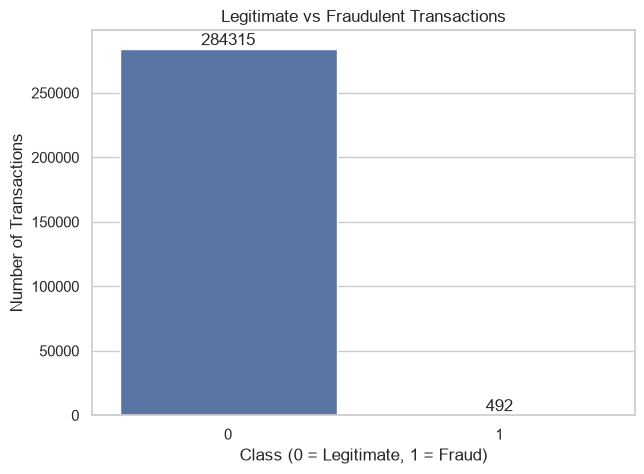

In [56]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Class"
)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 13. Statistical Summary

We inspect descriptive statistics for all numerical variables.

This provides an initial understanding of the scale, spread and
potential outliers in the dataset.

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 14. Transaction Amount Analysis

`Amount` represents the monetary value of each transaction.

We compare the transaction amount distribution between legitimate
and fraudulent transactions.

In [58]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


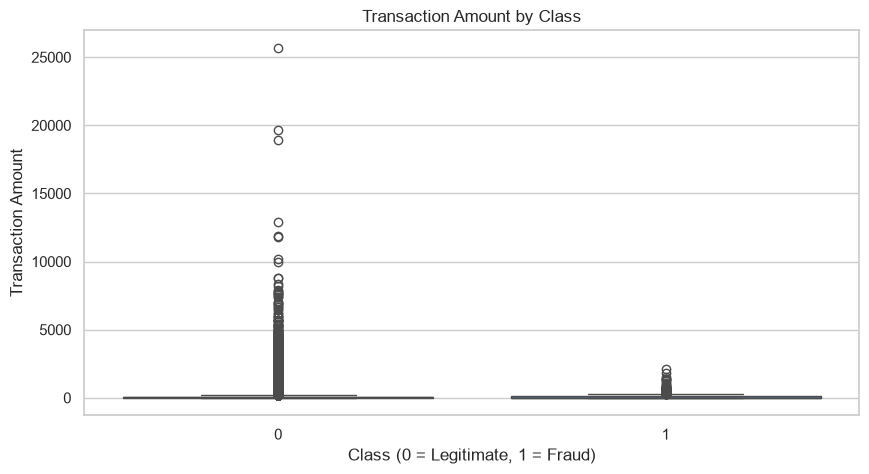

In [59]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

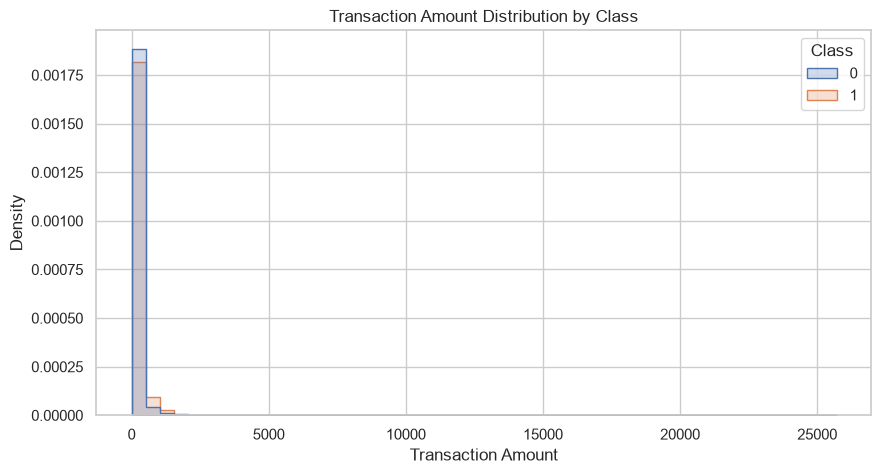

In [62]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

## 15. Transaction Time Analysis

`Time` represents the elapsed time in seconds from the first
transaction in the dataset.

We compare the timing distribution of legitimate and fraudulent
transactions to determine whether fraud occurrence varies across
the observation period.

In [63]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


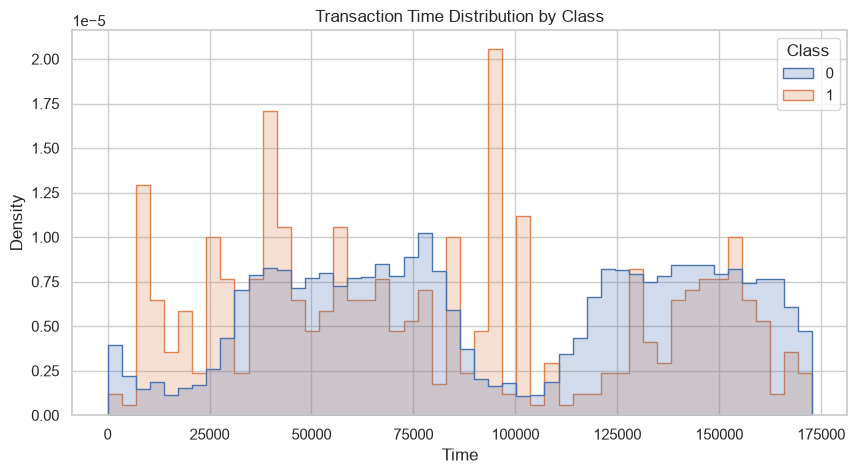

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

## 16. Anonymized Feature Analysis

The dataset contains 28 anonymized PCA-transformed features:

`V1` to `V28`

Their original business meanings are not available.

Therefore, we will analyze their statistical behavior without
assigning unsupported interpretations such as location, device type,
customer behavior or payment method.

In [65]:
v_features = [f"V{i}" for i in range(1, 29)]

feature_means = df.groupby("Class")[v_features].mean().T

feature_means.head(10)

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


## 17. Difference in Feature Means

We compare the absolute difference in average feature values between
fraudulent and legitimate transactions.

This is exploratory analysis only. It does not determine final
feature importance for the machine learning model.

In [67]:
mean_difference = (
    df[df["Class"] == 1][v_features].mean()
    - df[df["Class"] == 0][v_features].mean()
).abs().sort_values(ascending=False)

print("Top features by absolute difference in class means:")
print(mean_difference.head(10))

Top features by absolute difference in class means:
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
dtype: float64


## 18. Feature Distribution Comparison

We visualize several anonymized features to see whether their
distributions differ between legitimate and fraudulent transactions.

These visualizations are exploratory and do not imply a direct
business interpretation of the anonymized variables.

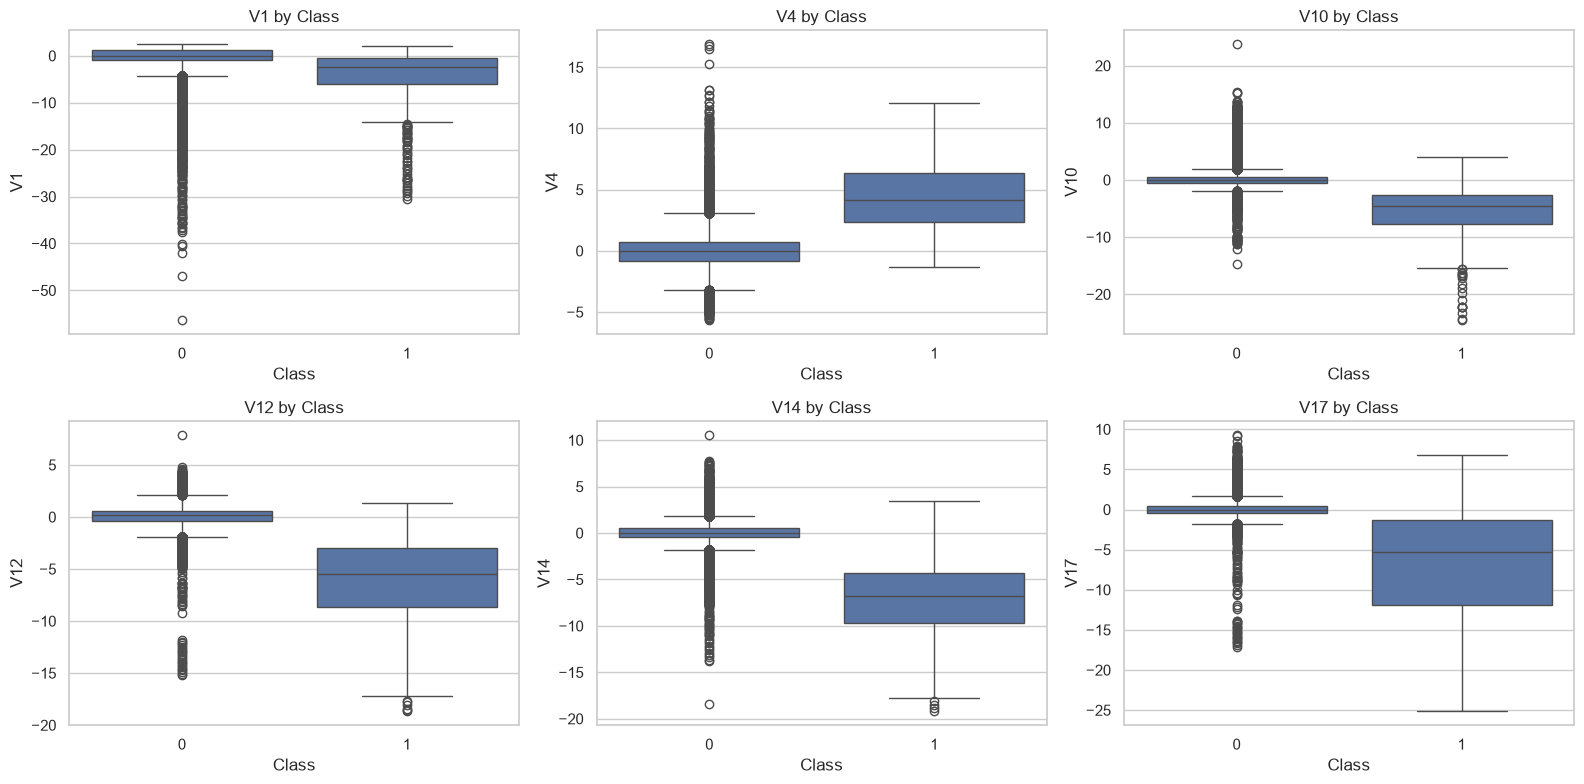

In [68]:
selected_features = [
    "V1",
    "V4",
    "V10",
    "V12",
    "V14",
    "V17"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8)
)

for ax, feature in zip(axes.flatten(), selected_features):

    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} by Class")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 19. Correlation Analysis

Correlation analysis helps identify linear relationships between
numerical variables.

Correlation does not prove causation and should not be interpreted
as a direct explanation of fraudulent behavior.

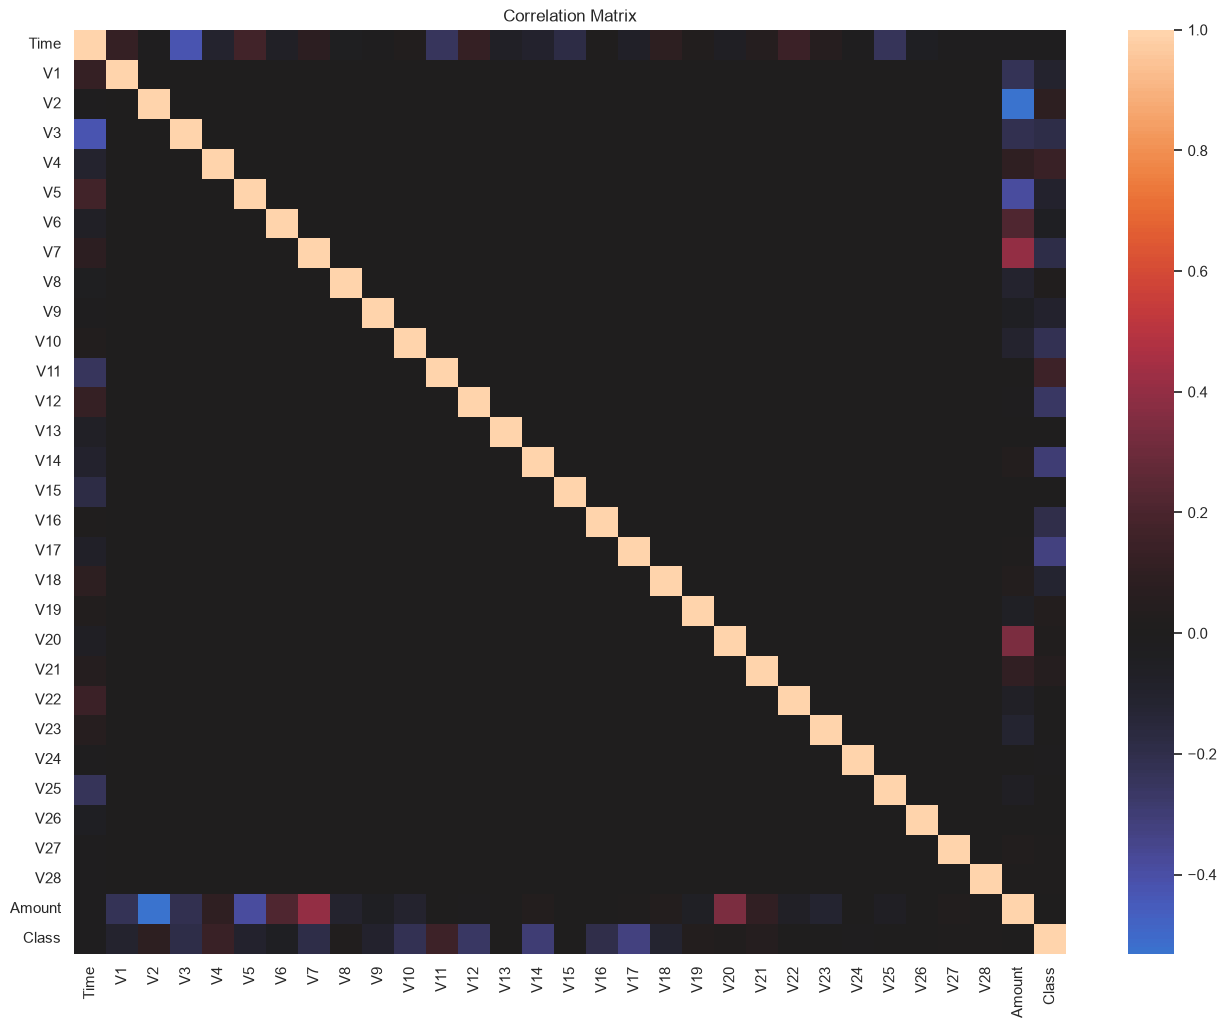

In [69]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 20. Features Correlated With the Fraud Target

We examine the absolute correlation between each numerical feature
and the target variable `Class`.

This is an exploratory analysis only. The final model will determine
predictive importance using the training data.

In [72]:
class_correlation = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

print("Top features by absolute correlation with Class:")
print(class_correlation.head(10))

Top features by absolute correlation with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


## 21. Fraud Transaction Amount Summary

We separately inspect the monetary distribution of fraudulent
transactions.

In [73]:
fraud_transactions = df[df["Class"] == 1]

print("Number of fraud transactions:", len(fraud_transactions))

print("\nFraud transaction amount statistics:")
print(fraud_transactions["Amount"].describe())

Number of fraud transactions: 492

Fraud transaction amount statistics:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


## 22. Legitimate Transaction Amount Summary

In [74]:
legitimate_transactions = df[df["Class"] == 0]

print(
    "Number of legitimate transactions:",
    len(legitimate_transactions)
)

print("\nLegitimate transaction amount statistics:")
print(legitimate_transactions["Amount"].describe())

Number of legitimate transactions: 284315

Legitimate transaction amount statistics:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


## 23. Fraud Rate Across Transaction Amount Groups

Transactions are divided into quantile-based amount groups.

We calculate the fraud rate within each group to investigate whether
fraud occurrence varies across transaction-value ranges.

This is exploratory analysis and will not create model features.

In [75]:
amount_bins = pd.qcut(
    df["Amount"],
    q=10,
    duplicates="drop"
)

amount_fraud_rate = (
    df.groupby(amount_bins, observed=True)["Class"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

amount_fraud_rate["fraud_rate_percent"] = (
    amount_fraud_rate["fraud_rate"] * 100
)

amount_fraud_rate

,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
Amount,,,,
"(-0.001, 1.0]",30492,181,0.005936,0.593598
"(1.0, 3.57]",26473,27,0.001020,0.101991
"(3.57, 8.91]",28559,36,0.001261,0.126055
"(8.91, 13.0]",28405,13,0.000458,0.045767
"(13.0, 22.0]",28714,14,0.000488,0.048757
"(22.0, 37.0]",28375,17,0.000599,0.059912
"(37.0, 59.8]",28366,24,0.000846,0.084608
"(59.8, 100.0]",28915,50,0.001729,0.172921
"(100.0, 203.0]",28050,45,0.001604,0.160428


## 24. Fraud Rate Across Time Groups

The observation period is divided into ten time groups.

We calculate the fraud rate in each group to investigate whether fraud
occurrence varies over the observation period.

In [76]:
time_bins = pd.qcut(
    df["Time"],
    q=10,
    duplicates="drop"
)

time_fraud_rate = (
    df.groupby(time_bins, observed=True)["Class"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

time_fraud_rate["fraud_rate_percent"] = (
    time_fraud_rate["fraud_rate"] * 100
)

time_fraud_rate

,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
Time,,,,
"(-0.001, 35027.0]",28482,93,0.003265,0.326522
"(35027.0, 47694.2]",28480,64,0.002247,0.224719
"(47694.2, 60776.0]",28483,47,0.001650,0.165011
"(60776.0, 73261.4]",28478,37,0.001299,0.129925
"(73261.4, 84692.0]",28481,28,0.000983,0.098311
"(84692.0, 120396.0]",28484,91,0.003195,0.319478
"(120396.0, 132929.0]",28480,24,0.000843,0.084270
"(132929.0, 145247.8]",28477,33,0.001159,0.115883
"(145247.8, 157640.4]",28481,53,0.001861,0.186089


## 25. Data Quality Summary

The following summary provides the main data-quality statistics
identified during exploratory analysis.

In [77]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Exact duplicate rows",
        "Legitimate transactions",
        "Fraud transactions"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Class"] == 0).sum(),
        (df["Class"] == 1).sum()
    ]
})

eda_summary

,Metric,Value
0,Number of rows,284807
1,Number of columns,31
2,Total missing values,0
3,Exact duplicate rows,1081
4,Legitimate transactions,284315
5,Fraud transactions,492


## 26. Key EDA Findings

The exploratory analysis should be interpreted using the calculated
results above.

### Dataset Structure

The dataset contains transaction-level numerical features, including
`Time`, `V1` to `V28`, `Amount`, and the binary target `Class`.

### Data Quality

The dataset contains no missing values.

Exact duplicate records are present and require a deliberate
preprocessing decision before model training.

### Class Imbalance

Fraudulent transactions represent only a small fraction of the
dataset.

This creates a severe class-imbalance problem and makes accuracy an
insufficient primary metric.

### Feature Characteristics

`V1` to `V28` are anonymized PCA-transformed features. Their original
business meanings are unavailable, so we will not assign unsupported
interpretations to them.

### Risk Management Implication

The fraud detector must balance two competing outcomes:

- detecting fraudulent transactions
- avoiding unnecessary disruption to legitimate transactions

This motivates the later use of precision, recall, PR-AUC,
threshold analysis and false-positive/false-negative cost.

## 27. EDA Conclusion

The dataset is suitable for developing a binary fraud detection model.

The main challenges identified during EDA are:

1. Severe class imbalance.
2. Presence of duplicate records.
3. Anonymized numerical features.
4. Different consequences for false-positive and false-negative
   predictions.

The next stage is data preprocessing and experimental design.

Before training any model, we will:

- define a leakage-safe train/test strategy
- decide how duplicate records should be handled
- prepare the numerical features
- preserve the held-out test set for final evaluation

The held-out test set will not be used for model selection or
threshold tuning.